In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from tqdm import tqdm
# from extract_features import GenerateFeatures
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import scale, StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE





Normalize entire data

In [2]:
features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_5s_yo_0.8.csv')
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)


X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

View label distribution

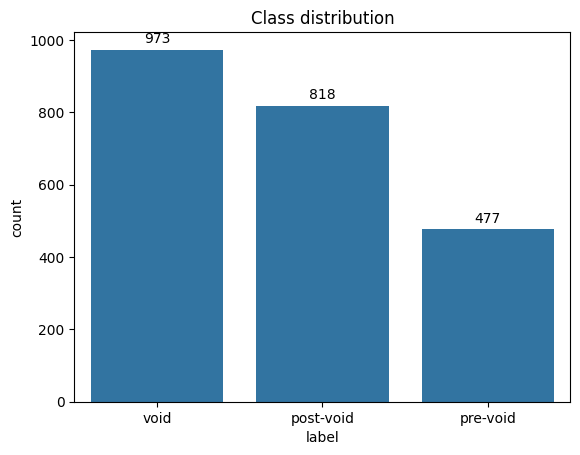

In [3]:
plt.figure()
ax = sns.countplot(x='label',
                   data=features,
                   order=features.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()


In [4]:
# Apply SMOTE to training data
# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



In [5]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
# y_train_encoded = label_encoder.fit_transform(y_train_smote) 
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [6]:
# model = XGBClassifier(random_state = 42)
model = RandomForestClassifier(random_state=42)

In [7]:
from sklearn import set_config
set_config(display="text")  # avoids estimator_html_repr

In [8]:
# eval_set = [(X_train_smote, y_train_encoded), (X_test, y_test_encoded)]
# model.fit(X_train_smote, y_train_encoded, eval_set=eval_set, verbose=False)

eval_set = [(X_train, y_train_encoded), (X_test, y_test_encoded)]
# model.fit(X_train, y_train_encoded, eval_set=eval_set, verbose=False)
model.fit(X_train, y_train_encoded)

RandomForestClassifier(random_state=42)

In [9]:
# classes = ['void', 'non-void']
classes = ['pre-void','void', 'post-void']

In [10]:
# Classification report
y_pred = label_encoder.inverse_transform(model.predict(X_test))
y_pred_prob = model.predict_proba(X_test)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred, labels=classes)

print(report)

              precision    recall  f1-score   support

    pre-void       0.29      0.50      0.37       103
        void       0.71      0.51      0.60       246
   post-void       0.58      0.57      0.58       261

    accuracy                           0.54       610
   macro avg       0.53      0.53      0.51       610
weighted avg       0.58      0.54      0.55       610



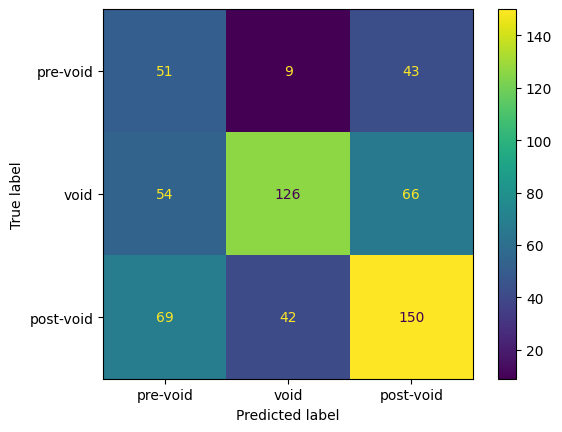

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = classes)
cm_display.plot()
plt.show()


In [12]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
plt.title('3s sliding window, 0.5 overlap, smote')
plt.legend()
plt.grid(True)
# plt.savefig('model_plots/two_class_results/loss_3s_0.5_smote.png')
plt.show()

AttributeError: 'RandomForestClassifier' object has no attribute 'evals_result'

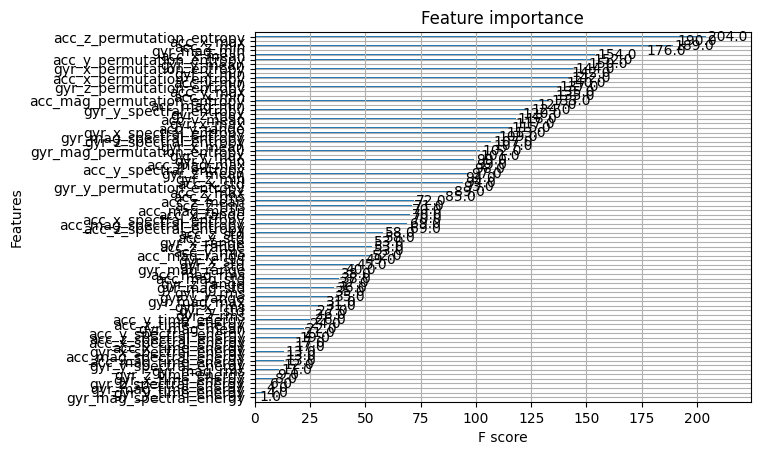

In [ ]:
plot_importance(model)
plt.show()

In [ ]:
# # Check class distribution after SMOTE
# unique, counts = np.unique(y_train_smote, return_counts=True)
# print(f"After SMOTE: {dict(zip(unique, counts))}")

# # Calculate new ratio (should be close to 1.0 if perfectly balanced)
# new_ratio = counts[0] / counts[1]  # negative/positive
# print(f"New scale_pos_weight should be: {new_ratio}")

In [ ]:
# # Encode string labels to integers
# label_encoder = LabelEncoder()

# # use SMOTE data
# y_train_encoded = label_encoder.fit_transform(y_train_smote) # replaced y_train with the y_train_smote

# # y_train_encoded = label_encoder.fit_transform(y_train) 
# y_test_encoded = label_encoder.transform(y_test)



# # Now train XGBoost
# model = XGBClassifier(
#     n_estimators=200,
#     max_depth=5,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric='logloss',
#     reg_alpha=0.1,   # L1 regularization
#     reg_lambda=1.0,  # L2 regularization
#     # early_stopping_rounds=10,
#     # scale_pos_weight=1.27,  # Adjust based on your imbalance
#     scale_pos_weight=new_ratio if abs(new_ratio - 1.0) > 0.1 else None,
#     verbosity=0
# )

# # eval_set = [(X_train, y_train_encoded), (X_test, y_test_encoded)] 
# # model.fit(X_train, y_train_encoded, eval_set=eval_set, verbose=False)  # Use encoded labels


# # use SMOTE data
# eval_set = [(X_train_smote, y_train_encoded), (X_test, y_test_encoded)] # replaced X_train with the X_train_smote
# model.fit(X_train_smote, y_train_encoded, eval_set=eval_set, verbose=False)  # Use encoded labels